# A neural surrogate for the two-phase flash calculation

**CHEN60492 *Properties of Subsurface Fluids* + the Deep Learning module**

This is a **synthetic surrogate benchmark**. The quantity being predicted is
the vapour fraction $F_V$ produced by the flash calculation taught in the
module — Wilson $K$-values fed into Rachford-Rice — evaluated on mixtures
generated for this study. There are no measurements anywhere in it, and none
of its numbers are a claim about real vapour–liquid equilibrium.

**The question.** The taught calculation finds $F_V$ by iterating on
Rachford-Rice. Can a small feed-forward network reproduce it for mixtures it
has never seen, **where does it fail**, and **when does adding the
Rachford-Rice residual to the loss improve the prediction**?

The project began as MSc coursework connecting the two modules. It was
rebuilt and re-verified in September 2026 (the six models and the metrics in
§4), then extended in October 2026: an error analysis across the two-phase
window (§4.2), a bounded network-capacity comparison (§6) and a guarded
prediction path (§7).

**Scope.** Only the Wilson route is modelled. The equation-of-state route to
$K$-values is named in the notes (p. 6) without an equation of state being
written down, and is outside the scope chosen here.

### What this notebook loads and what it computes

| section | loaded from disk | computed in this session |
|---|---|---|
| 1. physics and verification | the component table (`sfp/components.py`) | every verification number below |
| 2. dataset | `data/flash_dataset.npz`, `results/metrics/dataset.json` | the summary statistics and plots |
| 3. network and losses | — | $\lambda$, a 20-epoch smoke test |
| 4. results | the six checkpoints in `results/checkpoints/` | every metric, from those checkpoints |
| 4.2 error across the two-phase window | the same six checkpoints | window positions, boundary bands, every share quoted |
| 5. learning curve | `results/metrics/learning_curve.json` | the plot |
| 6. network capacity | the selection record `results/capacity/capacity_results.json`; the capacity checkpoints | test and extrapolation errors, from those checkpoints |
| 7. guarded prediction | `configs/prediction_domain.json`, the default checkpoint | every route and value shown |

All models were trained by `scripts/train.py` (200 epochs, three seeds per
variant and width); training is not repeated here. Everything else is
recomputed while the notebook runs.

### Sections

1. the physics, the component table, and the solver against the notes' worked examples
2. the dataset, and the split by mixture
3. the network and the two loss functions
4. results, and where in the two-phase window the error sits
5. error against the number of training mixtures
6. network capacity: 3 x 64, 3 x 128, 3 x 192 hidden units
7. guarded prediction: when the network is allowed to answer
8. what this does and does not show

In [1]:
import glob, json, os, sys, time
import numpy as np
import matplotlib.pyplot as plt
import torch

ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
sys.path.insert(0, os.path.join(ROOT, "src"))

from sfp import components as C, flash, data as sdata, nn as snn

print("python", sys.version.split()[0], "| torch", torch.__version__, "| device", snn.device)

python 3.11.15 | torch 2.14.0+cu130 | device cpu


---
## 1. The physics, the component table, and the solver

### 1.1 The equations

All from `Models/3 - Two-phase flash calculation.pdf`:

$$K_i=\frac{y_i}{x_i},\qquad z_i = x_i F_L + y_i F_V,\qquad F_V+F_L=1 \tag{p.\,2}$$

$$K_i=\frac{p_{ci}}{p}\,\exp\!\big[5.37\,(1+\omega_i)\,(1-T_{ci}/T)\big] \tag{Wilson, p.\,4 and p.\,14}$$

$$h(F_V)=\sum_i \frac{z_i\,(K_i-1)}{F_V(K_i-1)+1}=0 \tag{Rachford-Rice, p.\,8}$$

A mixture splits into two phases only where $\sum_i z_iK_i>1$ **and**
$\sum_i z_i/K_i>1$ (p. 8, table on p. 11). `sfp/flash.py` implements these and
nothing else, and finds the root by bisection so the iteration the network is
asked to replace stays visible.

### 1.2 The component table

Wilson needs $p_{ci}$, $T_{ci}$ and $\omega_i$. They are printed on **p. 14**
(spreadsheet example headed *Whitson's K-value Correlation*) and repeated on
p. 15. A page-by-page OCR sweep of all 139 pages of `Models/` found acentric
factors on those two pages and nowhere else. The values below are transcribed
verbatim, in the source's units — psia and degrees Rankine, with
$T[\mathrm{R}]=T[^\circ\mathrm{F}]+460$, the conversion the sheet itself uses —
and are not checked against or corrected by any outside table.

In [2]:
print(f"{'component':>10} {'Pc (psia)':>10} {'Tc (R)':>9} {'Tc (degF)':>10} {'omega (-)':>10} {'zi (-)':>10}")
for i, n in enumerate(C.NAMES):
    print(f"{n:>10} {C.PC_PSIA[i]:10.2f} {C.TC_RANKINE[i]:9.2f} "
          f"{C.TC_RANKINE[i]-460:10.2f} {C.OMEGA[i]:10.5f} {C.EXAMPLE_Z[i]:10.7f}")
print("\nsource: Models/3 - Two-phase flash calculation.pdf, pp. 14-15  [transcribed, not fitted]")

 component  Pc (psia)    Tc (R)  Tc (degF)  omega (-)     zi (-)
       CO2    1071.00    547.91      87.91    0.26670  0.0387597
        C1     666.40    343.33    -116.67    0.01040  0.1937984
        C2     706.50    549.92      89.92    0.09790  0.0775194
        C3     539.25    750.04     290.04    0.19235  0.1162791
        C4     481.00    818.68     358.68    0.22523  0.1085271
        C5     488.60    845.80     385.80    0.25140  0.1550388
       C10     359.84   1129.20     669.20    0.38900  0.3100775

source: Models/3 - Two-phase flash calculation.pdf, pp. 14-15  [transcribed, not fitted]


### 1.3 Verification against the notes' worked examples

A transcription can only be checked by reproducing the calculations the notes
themselves perform with it. Three cases follow, and the differences are
reported as measured rather than described as agreement.

**Case A (p. 14)** — bubble and dew point of that mixture at 150 °F. The notes
give $p_b = 1590.8769$ psia and $p_d = 1.9995691$ psia.

In [3]:
z = C.EXAMPLE_MOLES / C.EXAMPLE_MOLES.sum()          # z_i = n_i / sum(n_j), p. 2
T = 610.0                                            # R = 150 degF + 460
e = np.exp(5.37 * (1 + C.OMEGA) * (1 - C.TC_RANKINE / T))
pb = float((z * C.PC_PSIA * e).sum())                # p. 12: p_b = sum z_i p_ci exp[...]
pd = float(1.0 / (z / (C.PC_PSIA * e)).sum())        # p. 13: 1 = sum z_i / K_i

print(f"z rebuilt from the printed moles vs the printed zi : max |diff| = {np.abs(z - C.EXAMPLE_Z).max():.1e}")
print(f"p_b = {pb:12.4f} psia   notes 1590.8769 psia   relative difference {abs(pb-1590.8769)/1590.8769:.1e}")
print(f"p_d = {pd:12.7f} psia   notes    1.9995691 psia   relative difference {abs(pd-1.9995691)/1.9995691:.1e}")
print(f"closure: sum z_i K_i at p_b = {(z*flash.wilson_k(pb,T,C.TC_RANKINE,C.PC_PSIA,C.OMEGA)).sum():.6f}  (must be 1)")
print(f"closure: sum z_i/K_i at p_d = {(z/flash.wilson_k(pd,T,C.TC_RANKINE,C.PC_PSIA,C.OMEGA)).sum():.6f}  (must be 1)")

z rebuilt from the printed moles vs the printed zi : max |diff| = 5.0e-08
p_b =    1590.8767 psia   notes 1590.8769 psia   relative difference 1.3e-07
p_d =    1.9995763 psia   notes    1.9995691 psia   relative difference 3.6e-06
closure: sum z_i K_i at p_b = 1.000000  (must be 1)
closure: sum z_i/K_i at p_d = 1.000000  (must be 1)


Both saturation pressures land within a few parts per million of the printed
values, and both closure conditions hold to six decimals — enough to conclude
the table was transcribed correctly.

**Case B (p. 15)** — a full flash of the same mixture at 796.43821 psia and
180 °F. The notes print every $K_i$, the vapour fraction $f_v = 0.1917145$,
and all $x_i$ and $y_i$.

In [4]:
p, T = 796.43821, 640.0
K = flash.wilson_k(p, T, C.TC_RANKINE, C.PC_PSIA, C.OMEGA)
K_notes = np.array([3.57859, 10.34885, 2.03398, 0.22518, 0.09622, 0.07069, 0.00151])
FV, n_it = flash.solve_fv(z[None, :], K[None, :])
x, y = flash.phase_compositions(FV, z[None, :], K[None, :])
x_notes = np.array([0.025937, 0.069404, 0.064695, 0.136565, 0.131273, 0.188649, 0.383486])
y_notes = np.array([0.092819, 0.718255, 0.131588, 0.030751, 0.012630, 0.013335, 0.000579])

print(f"{'comp':>6} {'K here':>10} {'K notes':>10} | {'x here':>9} {'x notes':>9} | {'y here':>9} {'y notes':>9}")
for i, n in enumerate(C.NAMES):
    print(f"{n:>6} {K[i]:10.5f} {K_notes[i]:10.5f} | {x[0,i]:9.6f} {x_notes[i]:9.6f} | {y[0,i]:9.6f} {y_notes[i]:9.6f}")
print(f"\nmax |K - K_notes| after rounding to the printed 5 d.p. : {np.abs(np.round(K,5)-K_notes).max():.0e}")
print(f"max |x - x_notes| = {np.abs(x[0]-x_notes).max():.1e} ;  max |y - y_notes| = {np.abs(y[0]-y_notes).max():.1e}")
print(f"\nF_V bisection = {FV[0]:.7f}   notes f_v = 0.1917145   difference = {FV[0]-0.1917145:+.2e}")
print(f"residual h at our root        {flash.rachford_rice(FV, z[None,:], K[None,:])[0]:+.2e}")
print(f"residual h at the notes' f_v  {flash.rachford_rice(np.array([0.1917145]), z[None,:], K[None,:])[0]:+.2e}")
print(f"residual printed in the sheet's Target cell   +9.89e-06")
print(f"sum of the notes' printed y column            {y_notes.sum():.6f}  (their sheet prints 0.99996)")

  comp     K here    K notes |    x here   x notes |    y here   y notes
   CO2    3.57859    3.57859 |  0.025938  0.025937 |  0.092822  0.092819
    C1   10.34885   10.34885 |  0.069408  0.069404 |  0.718294  0.718255
    C2    2.03398    2.03398 |  0.064696  0.064695 |  0.131590  0.131588
    C3    0.22518    0.22518 |  0.136563  0.136565 |  0.030751  0.030751
    C4    0.09621    0.09622 |  0.131270  0.131273 |  0.012630  0.012630
    C5    0.07069    0.07069 |  0.188646  0.188649 |  0.013335  0.013335
   C10    0.00151    0.00151 |  0.383479  0.383486 |  0.000579  0.000579

max |K - K_notes| after rounding to the printed 5 d.p. : 1e-05
max |x - x_notes| = 7.1e-06 ;  max |y - y_notes| = 3.9e-05

F_V bisection = 0.1916985   notes f_v = 0.1917145   difference = -1.60e-05
residual h at our root        -6.17e-13
residual h at the notes' f_v  -5.19e-05
residual printed in the sheet's Target cell   +9.89e-06
sum of the notes' printed y column            0.999957  (their sheet prints 0.999

The $K$-values match every digit the sheet prints, and $x$ and $y$ agree to
within $7\times10^{-6}$ and $4\times10^{-5}$. The vapour fraction differs by
$1.6\times10^{-5}$.

**Why is not fully established.** The sheet's own `Target` cell prints a
non-zero residual, $9.89\times10^{-6}$, so it stopped short of the root, and
that is consistent with a difference of this size. But it is not the whole
story: the residual measured here at the sheet's own $f_v$ is
$-5.19\times10^{-5}$, and that value is not reproduced by any combination of
the printed (5 d.p.) or recomputed $K$ with the printed (8 d.p.) or recomputed
$z$. The sheet's $y$ column also sums to 0.99996 rather than 1. Something
beyond the stopping tolerance differs, and the evidence here does not identify
it — so the difference is reported, not explained away.

**Case C (pp. 16–18)** — the C1/nC10 binary. The notes print $F_V = 0.457$
where the closed forms they derive give 0.458888.

In [5]:
zb, Ka, Kb = np.array([[0.60, 0.40]]), np.array([[1.4, 0.13]]), np.array([[3.8, 0.0029]])

s1, s2 = flash.phase_sums(zb, Ka)
print(f"(a) 220 degF, 4000 psia:  sum z_i K_i = {s1[0]:.4f} (notes 0.89),  "
      f"sum z_i/K_i = {s2[0]:.4f} (notes 3.50)  ->  {flash.phase_label(zb, Ka)}")

FVb, _ = flash.solve_fv(zb, Kb)
xb, yb = flash.phase_compositions(FVb, zb, Kb)
K1, K2 = Kb[0]; z1, z2 = zb[0]
form1 = (1 - z1*K1 - z2*K2) / ((K1 - 1)*(K2 - 1))          # notes p. 17
form2 = (z1*(K1 - K2)/(1 - K2) - 1) / (K1 - 1)             # notes p. 18
drop  = (z1*K1 - 1) / (K1 - 1)                             # same, with K2 neglected against 1

print(f"\n(b) 160 degF, 1000 psia")
print(f"    bisection root                     = {FVb[0]:.7f}")
print(f"    notes' closed form 1 (p.17)        = {form1:.7f}")
print(f"    notes' closed form 2 (p.18)        = {form2:.7f}")
print(f"    same forms with K2 neglected vs 1  = {drop:.7f}   = (2.28 - 1)/2.8")
print(f"    full expression to 3 d.p.          = {round(form1,3)}")
print(f"    K2-neglected value to 3 d.p.       = {round(drop,3)}   <-- the value the notes print")

(a) 220 degF, 4000 psia:  sum z_i K_i = 0.8920 (notes 0.89),  sum z_i/K_i = 3.5055 (notes 3.50)  ->  liquid

(b) 160 degF, 1000 psia
    bisection root                     = 0.4588879
    notes' closed form 1 (p.17)        = 0.4588879
    notes' closed form 2 (p.18)        = 0.4588879
    same forms with K2 neglected vs 1  = 0.4571429   = (2.28 - 1)/2.8
    full expression to 3 d.p.          = 0.459
    K2-neglected value to 3 d.p.       = 0.457   <-- the value the notes print


$K_2 = 0.0029$ is about 0.3 % of 1. **Neglecting it against 1 in the binary
closed form reproduces the printed 0.457:**

$$F_V=\frac{z_1K_1-1}{K_1-1}=\frac{0.6\times3.8-1}{3.8-1}=\frac{1.28}{2.8}=0.4571428\ldots$$

The full expression gives 0.4588879, which to three decimals is 0.459, so the
printed figure is not the full expression rounded. The notes do not state this
approximation; it is offered as the numerical explanation consistent with
every figure they print, not as a claim about what was done. The same neglect
is also consistent with their $x$ and $y$:

In [6]:
def comps(fv, k2):
    return z1/(fv*(K1-1)+1), z2/(fv*(k2-1)+1)

xe, xd = comps(form1, K2), comps(drop, 0.0)
print(f"x from the full-expression F_V     = ({xe[0]:.4f}, {xe[1]:.4f})   -> (0.263, 0.737) to 3 d.p.")
print(f"x from the K2-neglected F_V        = ({xd[0]:.4f}, {xd[1]:.4f})   -> (0.263, 0.737) to 3 d.p.")
print(f"notes                              = (0.263, 0.737)")
print(f"\ny1 recomputed from their rounded x1: 0.263 x 3.8 = {0.263*K1:.4f} -> 0.999")
print(f"so their y2 = 1 - 0.999 = 0.001, whereas x2*K2 here = {xb[0,1]*K2:.5f}")
print(f"\nx rounds the same way on both routes, so only F_V separates them.")

x from the full-expression F_V     = (0.2626, 0.7374)   -> (0.263, 0.737) to 3 d.p.
x from the K2-neglected F_V        = (0.2632, 0.7368)   -> (0.263, 0.737) to 3 d.p.
notes                              = (0.263, 0.737)

y1 recomputed from their rounded x1: 0.263 x 3.8 = 0.9994 -> 0.999
so their y2 = 1 - 0.999 = 0.001, whereas x2*K2 here = 0.00214

x rounds the same way on both routes, so only F_V separates them.


---
## 2. The dataset

### 2.1 How mixtures are made

A **realisation** is one mixture: one feed composition $z$ over the seven
components above. Compositions follow the construction the notes use —
$z_i = n_i / \sum_j n_j$ from integer mole charges (flash notes p. 2, and the
`ni`/`zi` columns of the p. 14 table, where 5, 25, 10, 15, 14, 20, 40 moles
become the printed mole fractions). Here the mole charges are drawn as uniform
integers and normalised the same way, so mole fractions are non-negative and
sum to one by construction with no distribution assumed over the composition
simplex.

Each mixture is then evaluated at many $(p,T)$ states inside the window spanned
by the flash states the notes print, and only two-phase states are kept.

**Project choices, prescribed by nobody:** the mole-charge range (1–40; the
example's own charges run 5–40), 3,000 mixtures with 20 states each, the
log-uniform pressure draw, the 60/20/20 split proportions, the seeds, and the
2000 psia boundary between the training band and the extrapolation band.

### 2.2 Why the split is by mixture

Many rows share the same mixture. If rows were split at random, the network
would see a mixture at 600 psia in training and be tested on the same mixture
at 620 psia, and the test score would measure interpolation in pressure rather
than generalisation to new compositions. So every state of a mixture stays on
the same side of the split.

In [7]:
d = sdata.Domain()
print("sampling window                                            [units: psia, degrees Rankine]")
print(f"  T   {d.T_min_R:.0f} - {d.T_max_R:.0f} R   ({d.T_min_R-460:.0f} - {d.T_max_R-460:.0f} degF)")
print(f"  p   {d.p_min_psia:.0f} - {d.p_max_psia:.0f} psia   (training band ends at {d.p_max_train_psia:.0f} psia)")
print(f"  composition: {d.as_dict()['composition_rule']}")
print("\nthe printed states the window is spanned by (all Models/3 - ...):")
for T_, p_, where in C.SUPPLIED_STATES:
    print(f"  {T_:.0f} R / {p_:10.4f} psia   {where}")

sampling window                                            [units: psia, degrees Rankine]
  T   610 - 680 R   (150 - 220 degF)
  p   2 - 4000 psia   (training band ends at 2000 psia)
  composition: z_i = n_i / sum(n_j) from integer mole charges drawn uniformly in [1, 40] -- the construction of Models/3 - ... p. 2 and of the ni/zi columns on p. 14

the printed states the window is spanned by (all Models/3 - ...):
  610 R /  1590.8769 psia   p. 14, bubble point of the example mixture at 150 F
  610 R /     1.9996 psia   p. 14, dew point of the example mixture at 150 F
  640 R /   796.4382 psia   p. 15, flash of the example mixture at 180 F
  680 R /  4000.0000 psia   p. 16, C1/nC10 example, 220 F
  620 R /  1000.0000 psia   p. 17, C1/nC10 example, 160 F


In [8]:
blob = np.load(os.path.join(ROOT, "data", "flash_dataset.npz"))     # loaded
meta = json.load(open(os.path.join(ROOT, "results", "metrics", "dataset.json")))

for part in ("train", "val", "test"):
    q = meta[part]
    print(f"{part:>6}: {q['rows']:6d} rows  {q['realisations']:5d} mixtures   "
          f"p {q['p_psia_min']:7.1f}-{q['p_psia_max']:7.1f} psia   "
          f"F_V in [{q['FV_min']:.4f}, {q['FV_max']:.4f}] (-)")
e = meta["extrapolation"]
print(f"{'extrap':>6}: {e['rows']:6d} rows  {e['realisations_with_at_least_one_state']:5d} mixtures   "
      f"p {e['p_range_psia'][0]:7.1f}-{e['p_range_psia'][1]:7.1f} psia   mean F_V {e['FV_mean']:.4f} (-)")

print(f"\nmixtures shared between train and test: {meta['leakage_check_train_test_realisation_overlap']}")
print(f"of {meta['realisations_requested']} mixtures drawn, {meta['realisations_with_at_least_one_state']} "
      f"had at least one two-phase state.")
print(f"of {e['realisations_requested']} drawn for the extrapolation band, only "
      f"{e['realisations_with_at_least_one_state']} still split at 2000-4000 psia, so that set is selected, not random.")

# the composition rule, checked on the data that was actually loaded
n = blob["moles"]
print(f"\ncomposition check: max |z - n/sum(n)| = {np.abs(blob['z'] - n/n.sum(1, keepdims=True)).max():.1e}, "
      f"min z = {blob['z'].min():.4f}, max |sum z - 1| = {np.abs(blob['z'].sum(1)-1).max():.1e}")

 train:  36000 rows   1800 mixtures   p     2.1- 1999.5 psia   F_V in [0.0001, 1.0000] (-)
   val:  12000 rows    600 mixtures   p     2.1- 1999.4 psia   F_V in [0.0001, 1.0000] (-)
  test:  12000 rows    600 mixtures   p     2.5- 1999.6 psia   F_V in [0.0003, 1.0000] (-)
extrap:   7931 rows    401 mixtures   p  2000.0- 4000.0 psia   mean F_V 0.0625 (-)

mixtures shared between train and test: 0
of 3000 mixtures drawn, 3000 had at least one two-phase state.
of 600 drawn for the extrapolation band, only 401 still split at 2000-4000 psia, so that set is selected, not random.

composition check: max |z - n/sum(n)| = 0.0e+00, min z = 0.0048, max |sum z - 1| = 2.2e-16


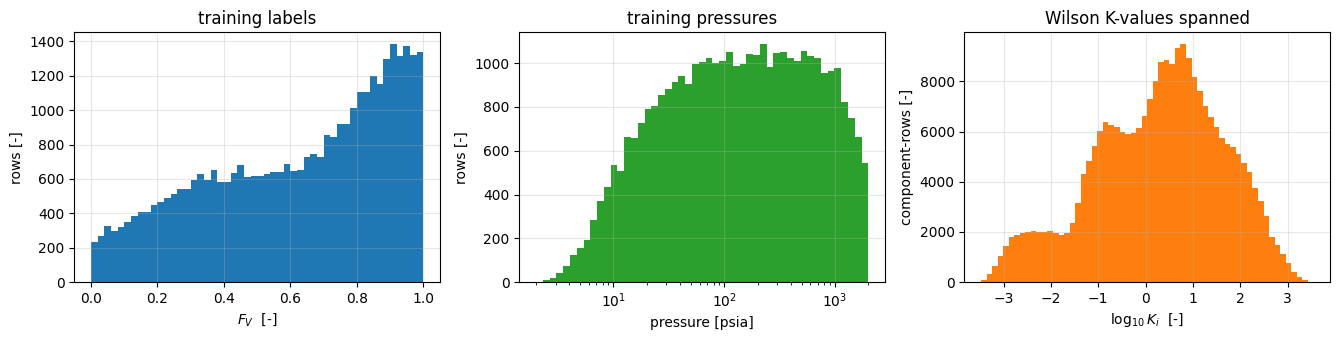

In [9]:
itr, ite = blob["idx_train"], blob["idx_test"]
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.5))
ax[0].hist(blob["FV"][itr], bins=50, color="C0")
ax[0].set_xlabel(r"$F_V$  [-]"); ax[0].set_ylabel("rows [-]"); ax[0].set_title("training labels")
ax[1].hist(blob["p_psia"][itr], bins=np.logspace(np.log10(2), np.log10(2000), 50), color="C2")
ax[1].set_xscale("log"); ax[1].set_xlabel("pressure [psia]"); ax[1].set_ylabel("rows [-]")
ax[1].set_title("training pressures")
ax[2].hist(np.log10(blob["K"][itr].ravel()), bins=60, color="C1")
ax[2].set_xlabel(r"$\log_{10} K_i$  [-]"); ax[2].set_ylabel("component-rows [-]")
ax[2].set_title("Wilson K-values spanned")
for a in ax: a.grid(alpha=0.3)
fig.tight_layout(); plt.show()

The vapour fraction covers the whole interval and the $K$-values span several
decades. The network is given raw pressure and temperature — not $1/p$ or
$\log p$ — so it has to learn the inverse-pressure dependence of the
$K$-values, and the exponential in $T$, before it can locate the root.

---
## 3. The network and the two loss functions

The architecture is the taught `simpleFFN`
(`Day01-Intro_DL_FFNs_and_Colab_morning_solutions.ipynb`, cell 23) with one
output instead of ten, `nn.ReLU` between hidden layers and `nn.Sigmoid` on the
output because $0<F_V<1$ by definition (flash notes p. 2).

Inputs are the nine numbers an engineer would type into the sheet on p. 15:
the seven mole fractions [-], the pressure [psia] and the temperature [R].
Standardisation statistics come from the training rows only (`Day01`, cell 29).
Width, depth, batch size, learning rate and epoch budget are project choices,
fixed once and identical for both variants.

**Loss A — data only**, the mean squared error of `Day02`/`Day03`:

$$L(\theta)=\frac{1}{N}\sum_i\big[\mathrm{NN}(x_i;\theta)-F_{V,i}\big]^2$$

**Loss B — data plus physics**, the structure of `Day13-SciML_morning.pdf`
slide 37 with Rachford-Rice in place of the slide's differential operator:

$$L(\theta)=\frac{1}{N}\sum_i\big[\mathrm{NN}(x_i;\theta)-F_{V,i}\big]^2
\;+\;\frac{\lambda}{N}\sum_i\Big[h\big(\mathrm{NN}(x_i;\theta);\,z_i,K_i\big)\Big]^2$$

The second term uses no label. $\lambda$ is measured rather than tuned: the
value that makes the two terms equal for the training-mean predictor, computed
on the training split alone.

In [10]:
snn.set_seed(0)
model = snn.simpleFFN(9, num_hidden=(128, 128, 128))
print(model)
print("parameters:", sum(p.numel() for p in model.parameters()))
print("inputs:", sdata.feature_names())

simpleFFN(
  (hidden_0): Linear(in_features=9, out_features=128, bias=True)
  (hidden_1): Linear(in_features=128, out_features=128, bias=True)
  (hidden_2): Linear(in_features=128, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=1, bias=True)
  (activation): ReLU()
  (output_activation): Sigmoid()
)
parameters: 34433
inputs: ['z_CO2', 'z_C1', 'z_C2', 'z_C3', 'z_C4', 'z_C5', 'z_C10', 'p_psia', 'T_R']


In [11]:
T_ = lambda a, dt=torch.float32: torch.as_tensor(a, dtype=dt)
lam, data_ref, phys_ref = snn.calibrate_lambda(T_(blob["FV"][itr]), T_(blob["z"][itr]), T_(blob["K"][itr]))
print(f"training-mean predictor:  MSE = {data_ref:.4f} [-],  mean h^2 = {phys_ref:.4f} [-]")
print(f"lambda* = MSE / mean h^2 = {lam:.4f} [-]")

h_at_labels = flash.rachford_rice(blob["FV"][itr], blob["z"][itr], blob["K"][itr])
print(f"\nsanity: mean h^2 at the labels themselves = {(h_at_labels**2).mean():.2e}  (should be ~0)")

training-mean predictor:  MSE = 0.0758 [-],  mean h^2 = 0.4352 [-]
lambda* = MSE / mean h^2 = 0.1742 [-]

sanity: mean h^2 at the labels themselves = 1.73e-24  (should be ~0)


That last line is what makes the physics term trustworthy: were the residual
not ~0 at the labels, the second term would pull the network away from the
answer rather than towards it.

The 20 epochs below exist so the training loop can be seen running. **These
numbers are not reported anywhere**; the six models scored in §4 were trained
by `scripts/train.py` for 200 epochs.

In [12]:
import torch.nn as tnn
from torch.utils.data import TensorDataset, DataLoader

scaler = sdata.Standardiser().fit(blob["X"][itr])
tr = (T_(scaler.transform(blob["X"][itr])), T_(blob["FV"][itr]), T_(blob["z"][itr]), T_(blob["K"][itr]))
loader = DataLoader(TensorDataset(*tr), batch_size=64, shuffle=True)

snn.set_seed(0)
demo = snn.simpleFFN(9, num_hidden=(128, 128, 128)).to(snn.device)
opt, crit = torch.optim.Adam(demo.parameters(), lr=1e-3), tnn.MSELoss()

t0 = time.time()
for epoch in range(20):
    loss, mse, rr2 = snn.train_one_epoch(demo, opt, crit, loader, lam)
    if epoch % 5 == 0 or epoch == 19:
        print(f"epoch {epoch:3d}   train MSE {mse:.3e} [-]   mean h^2 {rr2:.3e} [-]")
print(f"\n[smoke test only -- {time.time()-t0:.0f} s, not a reported result]")

epoch   0   train MSE 5.214e-03 [-]   mean h^2 4.088e-02 [-]


epoch   5   train MSE 5.034e-04 [-]   mean h^2 6.591e-03 [-]


epoch  10   train MSE 3.519e-04 [-]   mean h^2 4.700e-03 [-]


epoch  15   train MSE 2.743e-04 [-]   mean h^2 3.706e-03 [-]


epoch  19   train MSE 2.227e-04 [-]   mean h^2 3.056e-03 [-]

[smoke test only -- 25 s, not a reported result]


---
## 4. Results

Six models: two loss variants $\times$ three seeds, identical architecture and
epoch budget, parameters kept at the epoch of lowest **validation data MSE**,
the same criterion for both so the selection rule favours neither.

Two evaluation sets, both untouched by training:

* **test** — 600 mixtures never seen in training, same $(p,T)$ window;
* **extrapolation** — mixtures at 2000–4000 psia, above every training
  pressure, with a much lower mean $F_V$.

The metrics below are **recomputed now** from the saved checkpoints. $F_V$ is
dimensionless, so every error is in absolute vapour-fraction units.

In [13]:
def scores(true, pred, z_, K_):
    err = pred - true
    h = flash.rachford_rice(pred, z_, K_)
    return dict(rmse=float(np.sqrt((err**2).mean())),
                mae=float(np.abs(err).mean()),
                r2=float(1 - (err**2).sum() / ((true - true.mean())**2).sum()),
                mean_h2=float((h**2).mean()))

sets = {"test":          (blob["X"][ite], blob["FV"][ite], blob["z"][ite], blob["K"][ite]),
        "extrapolation": (blob["X_ood"],  blob["FV_ood"],  blob["z_ood"],  blob["K_ood"])}

rows, preds = {}, {}
for path in sorted(glob.glob(os.path.join(ROOT, "results", "checkpoints", "ffn_phys*_s*.pt"))):
    tag = os.path.splitext(os.path.basename(path))[0]
    ck = torch.load(path, map_location="cpu", weights_only=False)
    m = snn.simpleFFN(ck["n_inputs"], num_hidden=tuple(ck["hidden"])); m.load_state_dict(ck["model_state_dict"]); m.eval()
    sc = sdata.Standardiser().load_state_dict(ck["scaler"])
    rows[tag] = {"physics": bool(ck["args"]["physics"])}
    for name, (X_, y_, z_, K_) in sets.items():
        p_ = snn.predict(m, sc.transform(X_)).astype(float)
        preds[(tag, name)] = p_
        rows[tag][name] = scores(y_, p_, z_, K_)

mean_FV = blob["FV"][itr].mean()
base = {n: scores(v[1], np.full_like(v[1], mean_FV), v[2], v[3]) for n, v in sets.items()}

hdr = f"{'model':>16} | {'test RMSE':>10} {'test R2':>8} {'test h^2':>10} | {'extrap RMSE':>11} {'extrap R2':>9} {'extrap h^2':>11}"
print(hdr); print("-"*len(hdr))
print(f"{'training mean':>16} | {base['test']['rmse']:10.5f} {base['test']['r2']:8.3f} {base['test']['mean_h2']:10.2e} | "
      f"{base['extrapolation']['rmse']:11.5f} {base['extrapolation']['r2']:9.3f} {base['extrapolation']['mean_h2']:11.2e}")
for tag in sorted(rows):
    r = rows[tag]
    print(f"{tag:>16} | {r['test']['rmse']:10.5f} {r['test']['r2']:8.3f} {r['test']['mean_h2']:10.2e} | "
          f"{r['extrapolation']['rmse']:11.5f} {r['extrapolation']['r2']:9.3f} {r['extrapolation']['mean_h2']:11.2e}")
print("\nRMSE and h^2 are dimensionless (F_V is a fraction).")

           model |  test RMSE  test R2   test h^2 | extrap RMSE extrap R2  extrap h^2
-------------------------------------------------------------------------------------
   training mean |    0.27869   -0.000   4.42e-01 |     0.56222   -68.711    1.04e+00
    ffn_phys0_s0 |    0.00629    0.999   4.86e-04 |     0.00703     0.989    1.07e-04
    ffn_phys0_s1 |    0.00609    1.000   5.89e-04 |     0.01114     0.973    2.46e-04
    ffn_phys0_s2 |    0.00670    0.999   7.25e-04 |     0.00688     0.990    9.58e-05
    ffn_phys1_s0 |    0.00576    1.000   3.79e-04 |     0.00834     0.985    1.64e-04
    ffn_phys1_s1 |    0.00517    1.000   3.00e-04 |     0.00832     0.985    1.37e-04
    ffn_phys1_s2 |    0.00511    1.000   3.16e-04 |     0.01250     0.966    2.51e-04

RMSE and h^2 are dimensionless (F_V is a fraction).


In [14]:
summary = {}
print(f"{'variant':>22} | {'test RMSE [-]':>21} | {'extrapolation RMSE [-]':>23}")
print("-"*74)
for phys, label in ((False, "data loss only"), (True, "data + physics loss")):
    tags = [t for t in rows if rows[t]["physics"] == phys]
    ms = lambda name, key: (np.mean([rows[t][name][key] for t in tags]),
                            np.std([rows[t][name][key] for t in tags]))
    a, b = ms("test", "rmse"), ms("extrapolation", "rmse")
    summary[label] = {"test": a, "extrap": b}
    print(f"{label:>22} | {a[0]:11.5f} +/- {a[1]:.5f} | {b[0]:13.5f} +/- {b[1]:.5f}")

d0, d1 = summary["data loss only"]["test"][0], summary["data + physics loss"]["test"][0]
e0, e1 = summary["data loss only"]["extrap"][0], summary["data + physics loss"]["extrap"][0]
print(f"\ntest RMSE change with the physics term          : {100*(d1-d0)/d0:+.1f} %")
print(f"extrapolation RMSE change with the physics term : {100*(e1-e0)/e0:+.1f} %")
print("\nmean = arithmetic mean over seeds 0, 1, 2 of the per-seed metric.")
print("+/-  = population standard deviation (ddof=0) of those three values; it")
print("       measures variability from a different random initialisation and")
print("       shuffling order only -- the dataset and the split are identical")
print("       across seeds.  It is not a standard error or a confidence interval.")

               variant |         test RMSE [-] |  extrapolation RMSE [-]
--------------------------------------------------------------------------
        data loss only |     0.00636 +/- 0.00026 |       0.00835 +/- 0.00197
   data + physics loss |     0.00535 +/- 0.00029 |       0.00972 +/- 0.00197

test RMSE change with the physics term          : -15.9 %
extrapolation RMSE change with the physics term : +16.4 %

mean = arithmetic mean over seeds 0, 1, 2 of the per-seed metric.
+/-  = population standard deviation (ddof=0) of those three values; it
       measures variability from a different random initialisation and
       shuffling order only -- the dataset and the split are identical
       across seeds.  It is not a standard error or a confidence interval.


Both variants sit far below the training-mean baseline, which is the sanity
floor. Two findings, both reported:

* **In range, the physics term improved the test result.** Test RMSE falls by
  about 16 % (printed above), about three times the seed-to-seed spread, and
  the Rachford-Rice residual of the predictions falls with it.
* **On the reported pressure-extrapolation set, it did not.** There the
  physics-trained models are worse on average, and worse in two of the three
  seeds (§4.2). The average difference is about the same size as the
  seed-to-seed spread on either variant, so it is a change of sign rather
  than a firmly separated effect — but it is the measured result and it is
  reported as such. Whatever the residual term buys in range,
  robustness at 2000–4000 psia is not part of it in this benchmark.

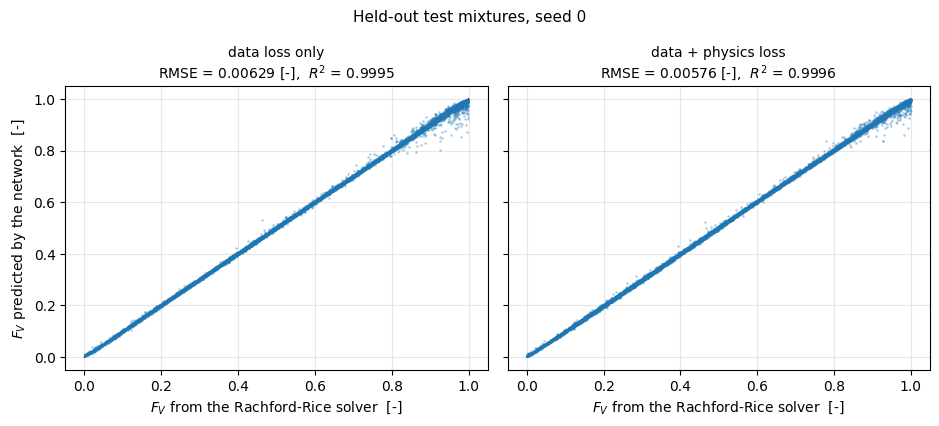

In [15]:
yte = sets["test"][1]
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.3), sharex=True, sharey=True)
for ax, phys in zip(axes, (0, 1)):
    tag = f"ffn_phys{phys}_s0"
    ax.plot([0, 1], [0, 1], "k-", lw=1)
    ax.plot(yte, preds[(tag, "test")], ".", ms=2, alpha=0.25)
    r = rows[tag]["test"]
    ax.set_title(("data + physics loss" if phys else "data loss only") +
                 f"\nRMSE = {r['rmse']:.5f} [-],  $R^2$ = {r['r2']:.4f}", fontsize=10)
    ax.set_xlabel(r"$F_V$ from the Rachford-Rice solver  [-]"); ax.grid(alpha=0.3)
axes[0].set_ylabel(r"$F_V$ predicted by the network  [-]")
fig.suptitle("Held-out test mixtures, seed 0", fontsize=11)
fig.tight_layout(); plt.show()

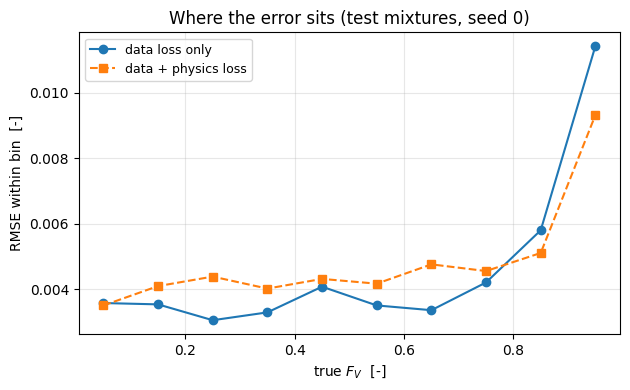

In [16]:
edges = np.linspace(0, 1, 11); centres = 0.5*(edges[:-1] + edges[1:])
fig, ax = plt.subplots(figsize=(6.4, 4.0))
for phys, style in ((0, "o-"), (1, "s--")):
    e_ = np.abs(preds[(f"ffn_phys{phys}_s0", "test")] - yte)
    m_ = [np.sqrt((e_[(yte >= a) & (yte < b)]**2).mean()) if ((yte >= a) & (yte < b)).any() else np.nan
          for a, b in zip(edges[:-1], edges[1:])]
    ax.plot(centres, m_, style, label="data + physics loss" if phys else "data loss only")
ax.set_xlabel(r"true $F_V$  [-]"); ax.set_ylabel(r"RMSE within bin  [-]")
ax.set_title("Where the error sits (test mixtures, seed 0)")
ax.legend(fontsize=9); ax.grid(alpha=0.3); fig.tight_layout(); plt.show()

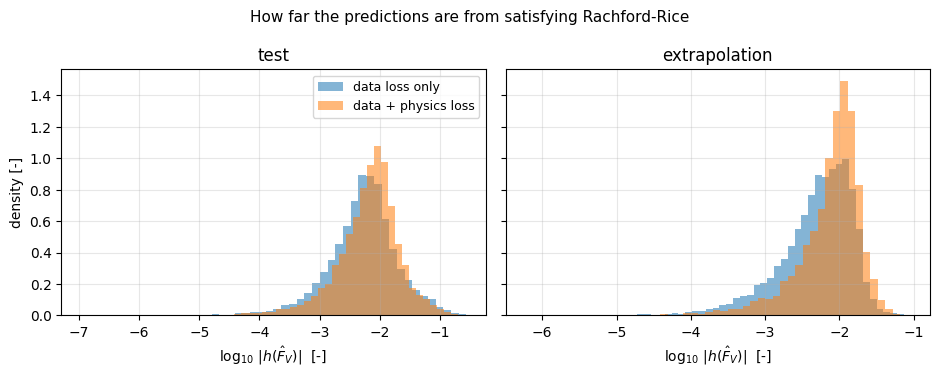

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), sharey=True)
for ax, name in zip(axes, ("test", "extrapolation")):
    z_, K_ = sets[name][2], sets[name][3]
    for phys, colour in ((0, "C0"), (1, "C1")):
        h_ = np.abs(flash.rachford_rice(preds[(f"ffn_phys{phys}_s0", name)], z_, K_))
        ax.hist(np.log10(np.maximum(h_, 1e-10)), bins=50, alpha=0.55, density=True, color=colour,
                label="data + physics loss" if phys else "data loss only")
    ax.set_xlabel(r"$\log_{10}\,|h(\hat{F}_V)|$  [-]"); ax.set_title(name); ax.grid(alpha=0.3)
axes[0].set_ylabel("density [-]"); axes[0].legend(fontsize=9)
fig.suptitle("How far the predictions are from satisfying Rachford-Rice", fontsize=11)
fig.tight_layout(); plt.show()

### 4.1 Cost of the iteration the surrogate replaces

Timed now, on this machine, over the whole test set.

In [18]:
Xte, yte_, zte, Kte = sets["test"]
ck = torch.load(os.path.join(ROOT, "results", "checkpoints", "ffn_phys0_s0.pt"),
                map_location="cpu", weights_only=False)
m = snn.simpleFFN(ck["n_inputs"], num_hidden=tuple(ck["hidden"])); m.load_state_dict(ck["model_state_dict"]); m.eval()
Xs = sdata.Standardiser().load_state_dict(ck["scaler"]).transform(Xte)

def timeit(fn, warmup=3, reps=15):
    for _ in range(warmup): fn()
    ts = []
    for _ in range(reps):
        t = time.perf_counter(); fn(); ts.append(time.perf_counter() - t)
    return float(np.median(ts))

t_solver, t_net = timeit(lambda: flash.solve_fv(zte, Kte)), timeit(lambda: snn.predict(m, Xs))
print(f"{len(yte_)} test rows, {torch.get_num_threads()} torch threads, device {snn.device}")
print(f"  bisection to 1e-12 (40 iterations) : {t_solver*1e3:7.1f} ms")
print(f"  one float32 forward pass           : {t_net*1e3:7.1f} ms")
print(f"  ratio (median of 15 repetitions)   : {t_solver/t_net:7.1f} x")

12000 test rows, 2 torch threads, device cpu
  bisection to 1e-12 (40 iterations) :    30.5 ms
  one float32 forward pass           :    14.1 ms
  ratio (median of 15 repetitions)   :     2.2 x


A 1-D bisection on a scalar monotone equation is already cheap, so replacing
it with a network of this size returns only a small factor while giving up
several digits of accuracy. The ratio also moves with whatever else the
machine is doing — repeated measurements on this container have spanned about
1.2× to 3.1× — so it is a rough figure, not a benchmark number. Either way,
speed is not the reason to build this surrogate.

### 4.2 Where in the two-phase window the error sits

Wilson's $K_i$ is proportional to $1/p$, so the phase test of p. 8 reduces to
$p_d < p < p_b$, with the bubble and dew points of pp. 12-13
($p_b=\sum_i z_i p_{ci}e^{5.37(1+\omega_i)(1-T_{ci}/T)}$, $1/p_d=\sum_i z_i/(p_{ci}e^{\dots})$
-- the `Bpi` and `Dpi` columns of the p. 14 sheet). Each row's position in its own
window is

$$\xi=\frac{\ln(p/p_d)}{\ln(p_b/p_d)}\qquad \xi=0 \text{ at the dew point } (F_V=1),\quad \xi=1 \text{ at the bubble point } (F_V=0).$$

The 5 % of test rows with the smallest $\xi$ are the *dew band*, the 5 % with the
largest the *bubble band*; the same $\xi$ limits are used for the extrapolation
set. `scripts/analyse_errors.py` writes the full tables to `results/analysis/`;
here the headline numbers are recomputed from the six checkpoints.

In [19]:
XI = {}
for name, s_ in sets.items():
    pb_, pd_ = flash.wilson_saturation_pressures(s_[2], s_[0][:, 8], C.TC_RANKINE, C.PC_PSIA, C.OMEGA)
    XI[name] = flash.window_position(s_[0][:, 7], pb_, pd_)
    assert ((XI[name] > 0) & (XI[name] < 1)).all()          # every row is two-phase

In [20]:
xs = np.sort(XI["test"]); k = int(round(0.05 * xs.size))
dew_max, bub_min = xs[k - 1], xs[xs.size - k]
print(f"dew band: xi <= {dew_max:.4f}   bubble band: xi >= {bub_min:.4f}   (5 % of test rows each)")
print(f"extrapolation rows: xi from {XI['extrapolation'].min():.3f} to {XI['extrapolation'].max():.3f} "
      f"-- all in the upper part of their windows\n")

def band_share(err, xi_):
    sse = (err**2).sum()
    return ((err[xi_ <= dew_max]**2).sum() / sse, (err[xi_ >= bub_min]**2).sum() / sse)

print(f"{'model':>14} | {'test: share of squared error':>30} | {'extrapolation':>24}")
print(f"{'':>14} | {'dew band':>14} {'bubble band':>15} | {'dew band':>11} {'bubble band':>12}")
for tag in sorted(rows):
    t_ = band_share(preds[(tag, "test")] - sets["test"][1], XI["test"])
    e_ = band_share(preds[(tag, "extrapolation")] - sets["extrapolation"][1], XI["extrapolation"])
    print(f"{tag:>14} | {t_[0]:14.1%} {t_[1]:15.1%} | {e_[0]:11.1%} {e_[1]:12.1%}")

print("\nphysics loss against data loss, same seed: RMSE change, and the share of the change in")
print("squared error that falls in the dew band")
for name in sets:
    for seed in (0, 1, 2):
        ea = preds[(f"ffn_phys0_s{seed}", name)] - sets[name][1]
        eb = preds[(f"ffn_phys1_s{seed}", name)] - sets[name][1]
        d_ = ea**2 - eb**2
        ch = 100 * (np.sqrt((eb**2).mean()) / np.sqrt((ea**2).mean()) - 1)
        print(f"  {name:>13} seed {seed}: RMSE {ch:+6.1f} %   dew-band share of the change "
              f"{d_[XI[name] <= dew_max].sum() / d_.sum() + 0.0:6.1%}")

dew band: xi <= 0.0464   bubble band: xi >= 0.9346   (5 % of test rows each)
extrapolation rows: xi from 0.806 to 1.000 -- all in the upper part of their windows

         model |   test: share of squared error |            extrapolation
               |       dew band     bubble band |    dew band  bubble band
  ffn_phys0_s0 |          58.3%            1.9% |        0.0%        87.7%
  ffn_phys0_s1 |          45.3%            1.9% |        0.0%        87.5%
  ffn_phys0_s2 |          50.4%            0.7% |        0.0%        83.4%
  ffn_phys1_s0 |          43.8%            2.6% |        0.0%        87.3%
  ffn_phys1_s1 |          56.4%            1.7% |        0.0%        88.1%
  ffn_phys1_s2 |          40.7%            1.9% |        0.0%        93.3%

physics loss against data loss, same seed: RMSE change, and the share of the change in
squared error that falls in the dew band
           test seed 0: RMSE   -8.3 %   dew-band share of the change 134.6%
           test seed 1: RMSE  -1

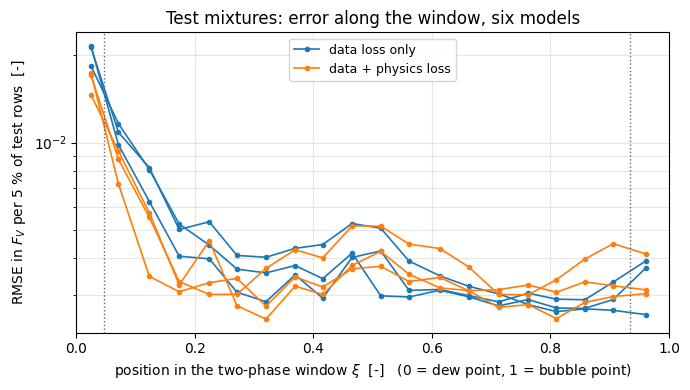

In [21]:
order = np.argsort(XI["test"]); groups = np.array_split(order, 20)
fig, ax = plt.subplots(figsize=(7.0, 4.0))
for tag in sorted(rows):
    e_ = preds[(tag, "test")] - sets["test"][1]
    ax.plot([np.median(XI["test"][g]) for g in groups], [np.sqrt((e_[g]**2).mean()) for g in groups],
            "o-", ms=3, lw=1.2, color="C1" if rows[tag]["physics"] else "C0",
            label=("data + physics loss" if rows[tag]["physics"] else "data loss only") if tag.endswith("s0") else None)
for v in (dew_max, bub_min): ax.axvline(v, color="0.4", ls=":", lw=1)
ax.set_yscale("log"); ax.set_xlim(0, 1)
ax.set_xlabel(r"position in the two-phase window $\xi$  [-]   (0 = dew point, 1 = bubble point)")
ax.set_ylabel(r"RMSE in $F_V$ per 5 % of test rows  [-]")
ax.set_title("Test mixtures: error along the window, six models"); ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

The error is concentrated next to the **dew point** -- where $F_V$ is close to 1
-- and the bubble-point side is not a problem area. The physics term lowered
the in-range error in every seed, but how much of that came from the dew band
varies from seed to seed, and on the pressure-extrapolation set it made the
error worse in two of the three seeds. `docs/ERROR_ANALYSIS.md` has the full
tables, including the error quantiles and a mixture-resampling check.

---
## 5. Error against the number of training mixtures

The same architecture and epoch budget trained on nested subsets of the
training mixtures (`scripts/learning_curve.py`), everything else fixed.

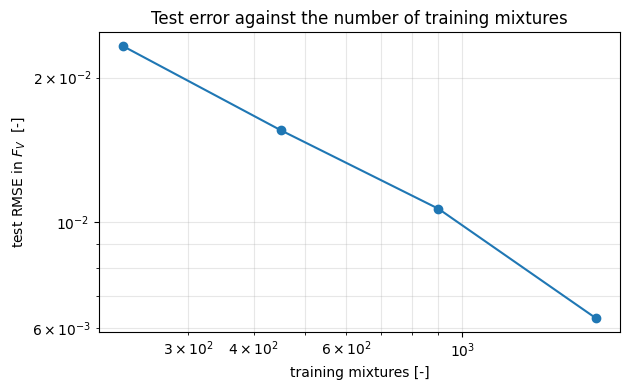

  225 mixtures -> test RMSE 0.02329 [-]
  450 mixtures -> test RMSE 0.01554 [-]
  900 mixtures -> test RMSE 0.01065 [-]
 1800 mixtures -> test RMSE 0.00629 [-]


In [22]:
lc = json.load(open(os.path.join(ROOT, "results", "metrics", "learning_curve.json")))   # loaded
fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.plot(lc["n_train_realisations"], lc["test_rmse"], "o-")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("training mixtures [-]"); ax.set_ylabel(r"test RMSE in $F_V$  [-]")
ax.set_title("Test error against the number of training mixtures")
ax.grid(alpha=0.3, which="both"); fig.tight_layout(); plt.show()
for n_, r_ in zip(lc["n_train_realisations"], lc["test_rmse"]):
    print(f"{n_:5d} mixtures -> test RMSE {r_:.5f} [-]")

Adding training mixtures reduced the test error at every step, and it was
still falling at the largest size tried. That says more data would help at
this architecture. On its own it does not say whether the width was right;
§6 compares widths directly.

---
## 6. Network capacity: 3 x 64, 3 x 128, 3 x 192 hidden units

Was the original width a sensible choice? The data-only network was trained at
three widths, three seeds each, with the same split, standardisation,
optimiser, epoch budget and checkpoint rule (`configs/capacity.json`, frozen and
committed before any of these models was scored on the test or extrapolation
sets). The original 3 x 128 runs were reused after their provenance was
checked; six new runs were added.

**Selection uses validation data only:** the smallest width whose mean best
validation MSE is within 10 % of the lowest. The test set is an *established
benchmark* — its 3 x 128 results were published before this comparison — so it
is reported, not used to choose. The physics-loss comparison of §4 was run at
3 x 128 only and is not extended to other widths here.

In [23]:
cap = json.load(open(os.path.join(ROOT, "results", "capacity", "capacity_results.json")))   # loaded
sel = cap["selection"]
print("selection (training records, validation data only):")
for w in (64, 128, 192):
    s_ = cap["summary_by_width"][str(w)]
    print(f"  3 x {w:3d}: {s_['n_parameters']:6d} parameters   mean best validation MSE "
          f"{s_['mean_best_val_mse']:.3e} +/- {s_['std_best_val_mse']:.1e}")
print(f"  threshold (lowest + 10 %): {sel['threshold']:.3e}  ->  selected 3 x {sel['selected_width']}"
      f"   (original 3 x {sel['original_width']})")

# test and extrapolation errors, recomputed now from the saved checkpoints
print("\nrecomputed from the checkpoints:")
cap_rmse = {}
for key, r in sorted(cap["runs"].items(), key=lambda kv: (kv[1]["width"], kv[1]["seed"])):
    ck = torch.load(os.path.join(ROOT, r["checkpoint"]), map_location="cpu", weights_only=False)
    m = snn.simpleFFN(ck["n_inputs"], num_hidden=tuple(ck["hidden"])); m.load_state_dict(ck["model_state_dict"]); m.eval()
    sc = sdata.Standardiser().load_state_dict(ck["scaler"])
    cap_rmse[key] = {n: float(np.sqrt(((snn.predict(m, sc.transform(sets[n][0])) - sets[n][1])**2).mean()))
                     for n in sets}
for w in (64, 128, 192):
    t_ = [cap_rmse[f"h{w}_s{s}"]["test"] for s in (0, 1, 2)]
    e_ = [cap_rmse[f"h{w}_s{s}"]["extrapolation"] for s in (0, 1, 2)]
    print(f"  3 x {w:3d}: test RMSE {np.mean(t_):.5f} +/- {np.std(t_):.5f}   "
          f"extrapolation RMSE {np.mean(e_):.5f} +/- {np.std(e_):.5f}  [-]")

selection (training records, validation data only):
  3 x  64:   9025 parameters   mean best validation MSE 5.162e-05 +/- 5.0e-06
  3 x 128:  34433 parameters   mean best validation MSE 5.624e-05 +/- 1.5e-06
  3 x 192:  76225 parameters   mean best validation MSE 5.720e-05 +/- 2.4e-06
  threshold (lowest + 10 %): 5.678e-05  ->  selected 3 x 64   (original 3 x 128)

recomputed from the checkpoints:


  3 x  64: test RMSE 0.00638 +/- 0.00028   extrapolation RMSE 0.00727 +/- 0.00209  [-]
  3 x 128: test RMSE 0.00636 +/- 0.00026   extrapolation RMSE 0.00835 +/- 0.00197  [-]
  3 x 192: test RMSE 0.00672 +/- 0.00028   extrapolation RMSE 0.00970 +/- 0.00128  [-]


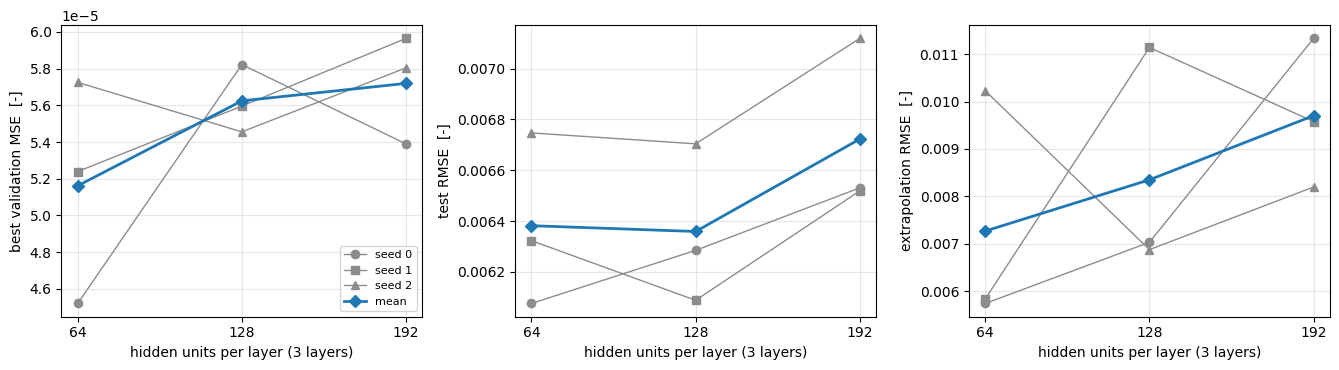

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
for ax, (lab, get) in zip(axes, (("best validation MSE  [-]", lambda k: cap["runs"][k]["best_val_mse"]),
                                 ("test RMSE  [-]", lambda k: cap_rmse[k]["test"]),
                                 ("extrapolation RMSE  [-]", lambda k: cap_rmse[k]["extrapolation"]))):
    for seed, mk in zip((0, 1, 2), ("o", "s", "^")):
        ax.plot((64, 128, 192), [get(f"h{w}_s{seed}") for w in (64, 128, 192)], mk + "-", color="0.55", lw=1,
                label=f"seed {seed}")
    ax.plot((64, 128, 192), [np.mean([get(f"h{w}_s{s}") for s in (0, 1, 2)]) for w in (64, 128, 192)],
            "D-", color="C0", lw=2, label="mean")
    ax.set_xticks((64, 128, 192)); ax.set_xlabel("hidden units per layer (3 layers)"); ax.set_ylabel(lab)
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8); fig.tight_layout(); plt.show()

`docs/CAPACITY.md` gives the parameter counts, training and inference times, the
training and validation curves, and the reading of this comparison.

---
## 7. Guarded prediction: when the network is allowed to answer

The sigmoid output returns a plausible-looking fraction for *any* input,
including single-phase states the network never saw. The public prediction
path, `sfp.predict.FlashSurrogate`, therefore validates the input (seven
components in the notes' order, finite, non-negative, summing to one, psia and
degrees Rankine), applies the course phase test first, and calls the network
only for two-phase states inside the training domain. Out-of-domain two-phase
states go to the reference solver, labelled as such, unless the caller asks
for an `unsupported` status or a marked extrapolation. `docs/GUARDED_PREDICTION.md`
has the details.

In [25]:
from sfp.predict import FlashSurrogate, InputError
surr = FlashSurrogate()
print("default model:", surr.model_name, "(lowest validation MSE of the six reported models)\n")
z_ex = C.EXAMPLE_MOLES / C.EXAMPLE_MOLES.sum()
pb_ex, pd_ex = (float(v[0]) for v in flash.wilson_saturation_pressures(z_ex[None], 610.0, C.TC_RANKINE, C.PC_PSIA, C.OMEGA))
cases = [("p. 15 flash, 796.4 psia, 640 R", z_ex, 796.43821, 640.0),
         ("p. 14 mixture at its dew point", z_ex, pd_ex, 610.0),
         ("p. 14 mixture at 1 psia (vapour)", z_ex, 1.0, 610.0),
         ("p. 14 mixture at 2500 psia (liquid)", z_ex, 2500.0, 610.0),
         ("p. 15 state at 700 R (outside 610-680 R)", z_ex, 796.43821, 700.0)]
print(f"{'case':<42}{'phase':<14}{'method':<28}{'F_V':>7}{'bare network':>14}")
for name, z_, p_, T_r in cases:
    r = surr.predict(z_, p_, T_r)
    bare = surr._network(z_[None], np.array([p_]), np.array([T_r]))[0]
    print(f"{name:<42}{r.phase:<14}{r.method:<28}{r.FV:7.4f}{bare:14.4f}")
try:
    surr.predict([0.6, 0.4], 1000.0, 620.0)            # the notes' C1/nC10 binary
except InputError as e:
    print("\nbinary of pp. 16-18 ->", e)

default model: ffn_phys1_s2 (lowest validation MSE of the six reported models)

case                                      phase         method                          F_V  bare network
p. 15 flash, 796.4 psia, 640 R            two_phase     network                      0.1923        0.1923
p. 14 mixture at its dew point            dew_point     phase_boundary               1.0000        0.8988
p. 14 mixture at 1 psia (vapour)          vapour        single_phase                 1.0000        0.9246
p. 14 mixture at 2500 psia (liquid)       liquid        single_phase                 0.0000        0.0000
p. 15 state at 700 R (outside 610-680 R)  two_phase     reference_solver_fallback    0.2547        0.2649

binary of pp. 16-18 -> composition has 2 mole fractions; the network covers only the seven-component set ['CO2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C10'] of the notes (pp. 14-15). Other mixtures, such as the C1/nC10 binary of pp. 16-18, can be flashed directly with sfp.flash


The bare network calls an all-vapour state about 92 % vapour and misses the
dew point by 0.10; the guarded path returns the phase test's answer and never
consults the network for either. The notes' binary verifies the reference
calculation (§1.3) but is not a seven-component state, so the network is not
allowed to answer it.

---
## 8. What this does and does not show

**Does.**

* The solver reproduces the notes' three worked examples to the tolerances
  measured in §1.3 — parts per million on the saturation pressures, every
  printed digit on the seven $K$-values — which is what licenses trusting the
  generated labels.
* A feed-forward network of the size taught in the course reproduces the
  taught flash calculation, on the module's own component table, for unseen
  compositions at the accuracy reported in §4, with the split done by mixture.
* Its errors are concentrated next to the **dew point**: about half of the
  squared error sits in the 5 % of test rows nearest it (§4.2).
* Adding the Rachford-Rice residual to the loss improved the in-range test
  result in every seed, but on the pressure-extrapolation set it made the
  error worse in two of the three seeds.
* A network a quarter of the size (3 x 64) matches 3 x 128 on the test set and
  is the one the frozen validation rule selects (§6).
* The guarded prediction path applies the phase test first and calls the
  network only inside its training domain (§7).

**Does not.**

* Say anything about real vapour–liquid equilibrium. This is a synthetic
  benchmark whose ground truth is the Wilson–Rachford-Rice calculation itself.
  The notes give Wilson's original validity as below 500 psia and then use it
  in their own examples up to 4000 psia; this project follows the notes.
* Cover the equation-of-state route to $K$-values, which is outside the scope
  chosen here (a separate future study).
* Correct the component constants. They are used exactly as printed.
* Transfer to another component set: one fixed set of seven components in
  varying proportions, with the network never told what the components are.
* Certify coverage: the guarded predictor's domain checks are marginal, one
  variable at a time.
* Give a random out-of-distribution sample: at 2000–4000 psia many mixtures
  have no two-phase state, so the extrapolation set is selected.
* Establish significance. Three seeds show whether an effect exceeds seed
  scatter; the ± is a standard deviation over seeds and nothing more.
* Extend the physics-loss finding beyond the 3 x 128 network it was measured on.

`docs/LIMITATIONS.md` carries the full list. `docs/SOURCE_MAP.md` traces every
equation, property value, architecture and loss term to a page or a notebook
cell, and §5 there lists every project choice that is not from the material.